In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine


In [42]:
engine = create_engine(
    "mssql+pyodbc:/YOUR_SEVER_NAME\\SQLEXPRESS/ECOMMERCE"
    "?driver=SQL+Server&trusted_connection=yes"
)
print("✅ Connected to SQL Server — ECOMMERCE database")


✅ Connected to SQL Server — ECOMMERCE database


In [43]:
df_customers   = pd.read_sql("SELECT * FROM CUSTOMERS",   engine)
df_products    = pd.read_sql("SELECT * FROM PRODUCTS",    engine)
df_orders      = pd.read_sql("SELECT * FROM ORDERS",      engine)
df_order_items = pd.read_sql("SELECT * FROM ORDER_ITEMS", engine)

df_customers.head(), df_products.head(), df_orders.head(), df_order_items.head()


C:\Users\DELL\anaconda3\Lib\site-packages\pandas\io\sql.py:1539: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


(   customer_id customer_name             email phone_number       city  age  \
 0            1           Ali     ali@gmail.com  03001234567  Hyderabad   28   
 1            2          Raha  raha24@gmail.com   1293548460     Mumbai   25   
 2            3          John  john10@gmail.com   1293808460      Delhi   32   
 3            4         Sammy   sam13@gmail.com   0296548460  Bangalore   22   
 4            5          Dina   din12@gmail.com   3290548760    Chennai   35   
 
    gender  
 0    Male  
 1  Female  
 2    Male  
 3  Female  
 4  Female  ,
    product_id product_name    price     category  cost_price  stock_quantity
 0         101       Laptop  60000.0  Electronics     15000.0              50
 1         102        Watch   4000.0  Electronics      3000.0              30
 2         103       Camera  10000.0  Electronics      7000.0              20
 3         104          Bag   1000.0  Accessories       500.0             100
 4         105       Mobile  25000.0  Electronics

In [44]:
df_orders.dtypes
df_orders.describe()
df_customers.isnull().sum(), df_products.isnull().sum(), df_orders.isnull().sum(), df_order_items.isnull().sum()


(customer_id      0
 customer_name    0
 email            1
 phone_number     1
 city             0
 age              0
 gender           0
 dtype: int64,
 product_id        0
 product_name      0
 price             0
 category          0
 cost_price        0
 stock_quantity    0
 dtype: int64,
 order_id          0
 customer_id       0
 order_date        0
 total_amount      0
 status            0
 payment_method    0
 discount          0
 dtype: int64,
 order_item_id    0
 order_id         0
 product_id       0
 quantity         0
 dtype: int64)

In [45]:
df_customers   = df_customers.dropna()
df_products    = df_products.dropna()
df_orders      = df_orders.dropna()
df_order_items = df_order_items.dropna()

df_orders["order_date"] = pd.to_datetime(df_orders["order_date"])
df_orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        17 non-null     int64         
 1   customer_id     17 non-null     int64         
 2   order_date      17 non-null     datetime64[ns]
 3   total_amount    17 non-null     float64       
 4   status          17 non-null     object        
 5   payment_method  17 non-null     object        
 6   discount        17 non-null     float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(2)
memory usage: 1.1+ KB


CUSTOMERS | age: Q1=25, Q3=32, IQR=7, Outliers=0
PRODUCTS | price: Q1=2900, Q3=19000, IQR=16100, Outliers=2
PRODUCTS | cost_price: Q1=1375, Q3=12750, IQR=11375, Outliers=1
PRODUCTS | stock_quantity: Q1=15, Q3=58, IQR=42, Outliers=1
ORDERS | total_amount: Q1=2000, Q3=20000, IQR=18000, Outliers=1
ORDERS | discount: Q1=0, Q3=200, IQR=200, Outliers=0
ORDER_ITEMS | quantity: Q1=1, Q3=3, IQR=2, Outliers=0


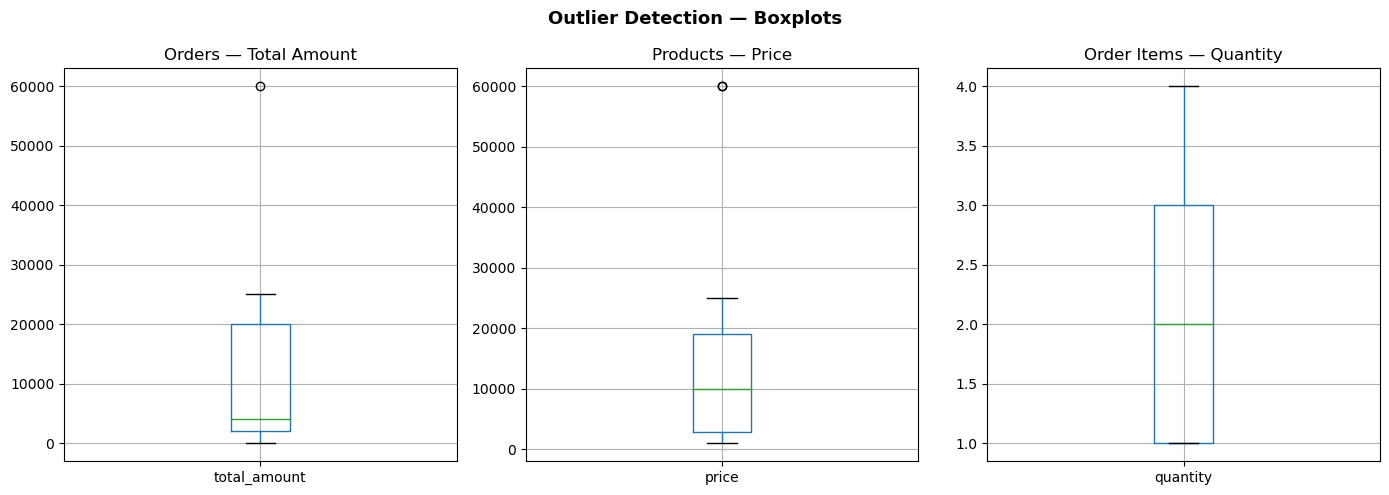

In [46]:
numeric_columns = [
    ("age",            df_customers,   "CUSTOMERS"),
    ("price",          df_products,    "PRODUCTS"),
    ("cost_price",     df_products,    "PRODUCTS"),
    ("stock_quantity", df_products,    "PRODUCTS"),
    ("total_amount",   df_orders,      "ORDERS"),
    ("discount",       df_orders,      "ORDERS"),
    ("quantity",       df_order_items, "ORDER_ITEMS"),
]

for col, df, table in numeric_columns:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{table} | {col}: Q1={Q1:.0f}, Q3={Q3:.0f}, IQR={IQR:.0f}, Outliers={len(outliers)}")

# Combined boxplots
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
df_orders.boxplot(      column=["total_amount"], ax=axes[0])
df_products.boxplot(    column=["price"],        ax=axes[1])
df_order_items.boxplot( column=["quantity"],     ax=axes[2])
axes[0].set_title("Orders — Total Amount")
axes[1].set_title("Products — Price")
axes[2].set_title("Order Items — Quantity")
plt.suptitle("Outlier Detection — Boxplots", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [48]:
df_products["profit_per_unit"]   = df_products["price"] - df_products["cost_price"]
df_products["profit_margin_pct"] = (
    (df_products["price"] - df_products["cost_price"]) / df_products["price"] * 100
).round(2)

df_orders["net_amount"]  = df_orders["total_amount"] - df_orders["discount"]
df_orders["month"]       = df_orders["order_date"].dt.month
df_orders["month_name"]  = df_orders["order_date"].dt.strftime("%B")
df_orders["year"]        = df_orders["order_date"].dt.year


In [49]:
print(df_products[["profit_per_unit","profit_margin_pct"]].describe())
print(df_orders[["net_amount"]].describe())


       profit_per_unit  profit_margin_pct
count         12.00000           12.00000
mean        7700.00000           42.37250
std        12497.63614           16.52321
min          500.00000           25.00000
25%         1150.00000           29.05750
50%         3000.00000           40.00000
75%         7500.00000           52.98500
max        45000.00000           75.00000
         net_amount
count     17.000000
mean   11774.647059
std    15199.451951
min        0.000000
25%     1850.000000
50%     4000.000000
75%    19500.000000
max    59700.000000


In [50]:
# BI-1: Overall Revenue Summary
df_orders["total_amount"].sum(), df_orders["discount"].sum(), df_orders["net_amount"].sum()

# BI-2: Revenue & Orders per Customer
df_orders.merge(df_customers, on="customer_id").groupby("customer_name")["total_amount"].sum().sort_values(ascending=False)

# BI-3: Monthly Revenue Trend
df_orders.groupby("month_name")["total_amount"].sum()

# BI-4: Revenue by Status
df_orders.groupby("status")["total_amount"].sum()

# BI-5: Top Products by Units Sold
df_order_items.merge(df_products, on="product_id").groupby("product_name")["quantity"].sum().sort_values(ascending=False)

# BI-6: Product Profit Margin
df_products[["product_name","profit_margin_pct"]].sort_values("profit_margin_pct", ascending=False)


,product_name,profit_margin_pct
0,Laptop,75.00
6,Shirt,60.00
8,Shoes,53.12
10,Tablet,52.94
3,Bag,50.00
11,Headphones,50.00
2,Camera,30.00
7,Camera,30.00
9,Laptop,29.41
4,Mobile,28.00


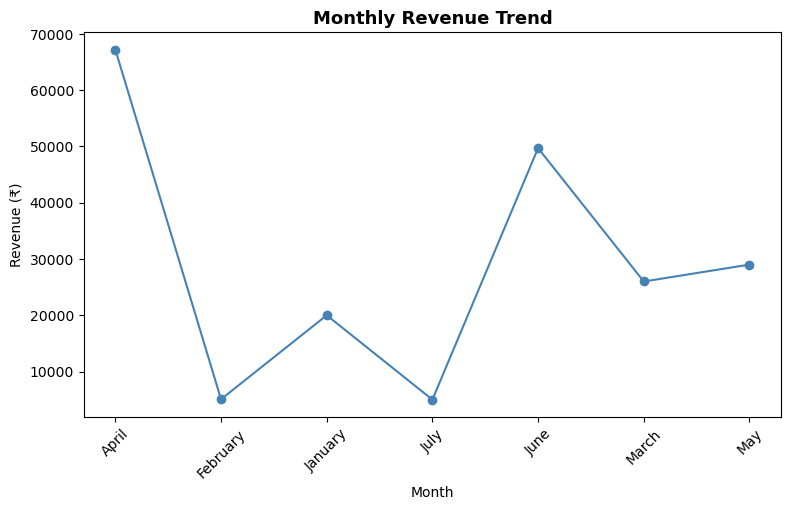

In [51]:
# Example: Monthly Revenue Trend
df_monthly = df_orders.groupby("month_name")["total_amount"].sum().reset_index()
plt.figure(figsize=(9,5))
plt.plot(df_monthly["month_name"], df_monthly["total_amount"], marker="o", color="steelblue")
plt.title("Monthly Revenue Trend", fontsize=13, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.show()


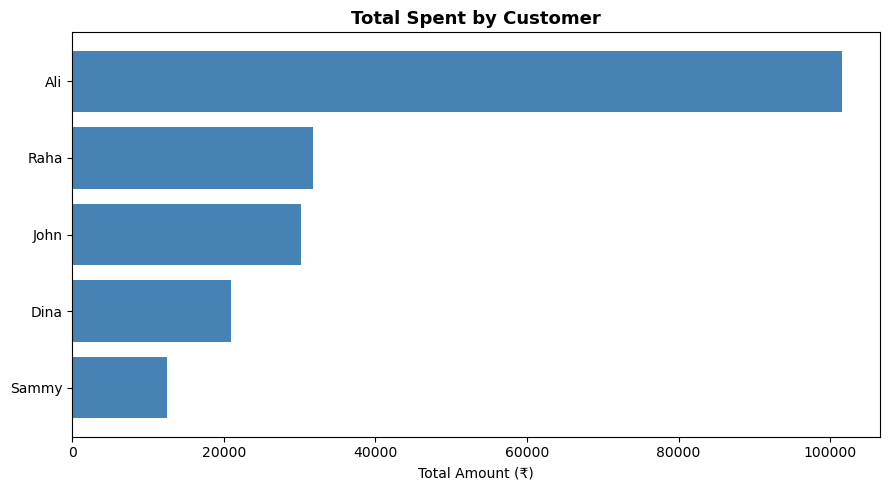

In [52]:
df_cust_spent = (
    pd.merge(df_orders, df_customers, on="customer_id")
    .groupby("customer_name")["total_amount"]
    .sum().reset_index()
    .sort_values("total_amount", ascending=True)
)

plt.figure(figsize=(9, 5))
plt.barh(df_cust_spent["customer_name"],
         df_cust_spent["total_amount"], color="steelblue")
plt.title("Total Spent by Customer", fontsize=13, fontweight="bold")
plt.xlabel("Total Amount (₹)")
plt.tight_layout()
plt.show()


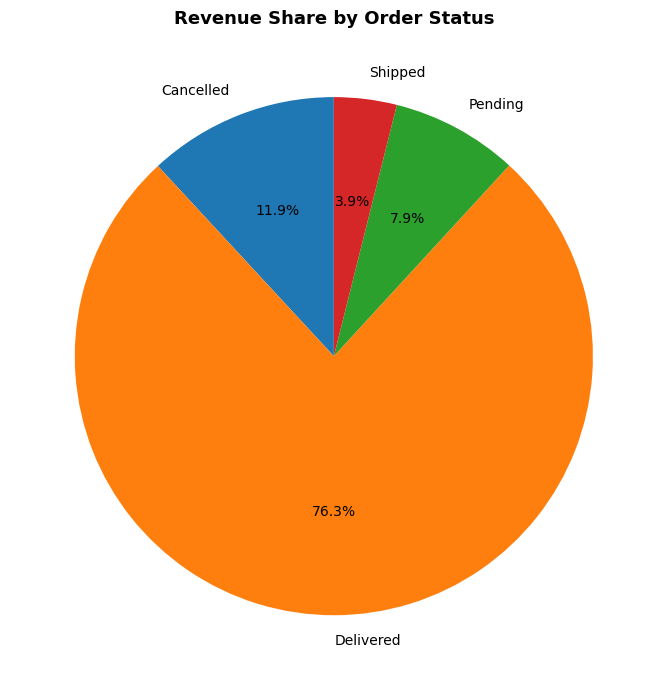

In [53]:
df_pie = df_orders.groupby("status")["total_amount"].sum()

plt.figure(figsize=(7, 7))
plt.pie(df_pie.values, labels=df_pie.index, autopct="%1.1f%%", startangle=90)
plt.title("Revenue Share by Order Status", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [55]:
# Create df_bi5: Top Products by Units Sold
df_bi5 = (
    pd.merge(df_order_items, df_products, on="product_id")
    .groupby("product_name")
    .agg(units_sold=("quantity","sum"))
    .reset_index()
    .sort_values("units_sold", ascending=False)
)

df_bi5.head()  # preview


,product_name,units_sold
2,Camera,14
4,Mobile,7
3,Laptop,5
5,Shirt,5
6,Shoes,5


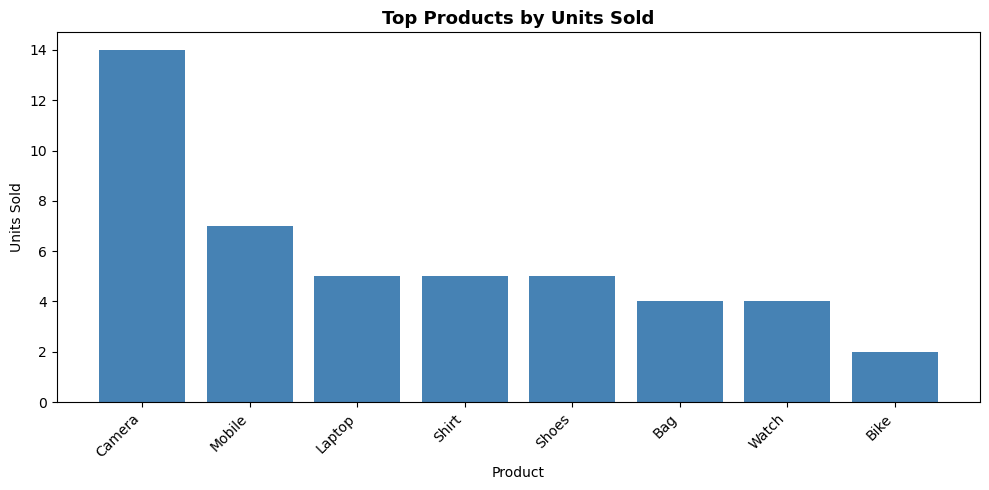

In [56]:
plt.figure(figsize=(10, 5))
plt.bar(df_bi5["product_name"], df_bi5["units_sold"], color="steelblue")
plt.title("Top Products by Units Sold", fontsize=13, fontweight="bold")
plt.xlabel("Product")
plt.ylabel("Units Sold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
